In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.colors as mcolors

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
idir    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/final/'
ds_traj = xr.open_dataset(idir+'dataset_traj.nc')
ds_temp = xr.open_dataset(idir+'dataset_temp.nc')
ds_wave = xr.open_dataset(idir+'dataset_wave.nc')

In [37]:
ds = ds_temp
ds

<xarray.Dataset>
Dimensions:                      (tr_nr: 33, time_ds: 2929, model: 9, lt_int: 8)
Coordinates:
  * tr_nr                        (tr_nr) int64 1 2 3 4 6 7 ... 29 30 31 32 34 35
  * time_ds                      (time_ds) datetime64[ns] 2024-04-01 ... 2024...
  * model                        (model) object 'DWD-ICON' ... 'MF-ARPEGE'
  * lt_int                       (lt_int) object ']0_12]' ... ']84_96]'
Data variables: (12/31)
    lat_obs                      (tr_nr, time_ds) float64 ...
    lon_obs                      (tr_nr, time_ds) float64 ...
    temp_1m_calibrated           (tr_nr, time_ds) float64 ...
    temp_10cm_calibrated         (tr_nr, time_ds) float64 ...
    temp_snowsurface_calibrated  (tr_nr, time_ds) float64 ...
    temp_snowice_calibrated      (tr_nr, time_ds) float64 ...
    ...                           ...
    sldr                         (model, lt_int, tr_nr, time_ds) float64 ...
    slur                         (model, lt_int, tr_nr, time_ds) float64 ...
    ssdr                         (model, lt_int, tr_nr, time_ds) float64 ...
    ssur                         (model, lt_int, tr_nr, time_ds) float64 ...
    temp_flag_cons               (tr_nr, time_ds) float64 ...
    temp_flag_1m                 (tr_nr, time_ds) float64 ...

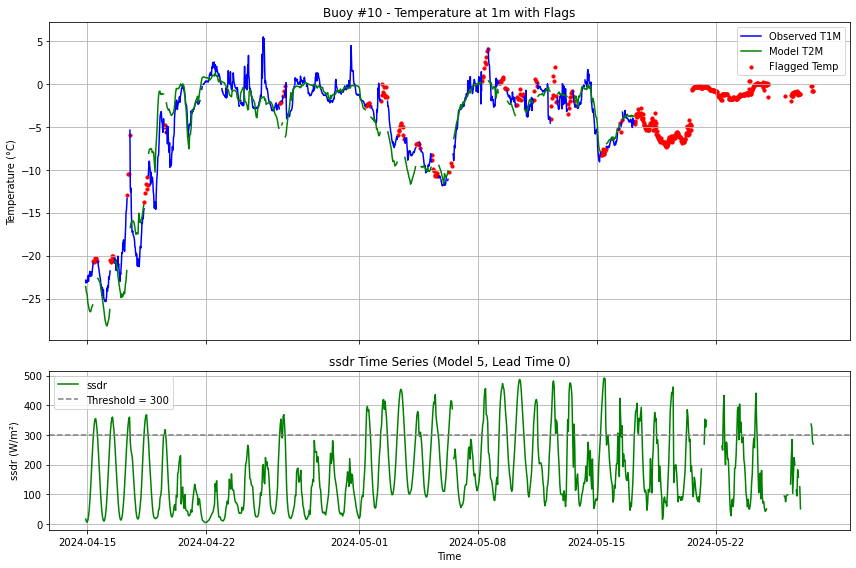

In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Select one buoy index
tr_idx    = 10
model_idx = 5
ltint     = 0

# Extract time and variables
time = ds['time_ds']
tempraw = ds['temp_1m_calibrated'][tr_idx, :] - 273.15
modelraw= ds['T2M'][model_idx, ltint, tr_idx, :] - 273.15
flag1 = ds['temp_flag_1m'][tr_idx, :]
flag2 = ds['temp_flag_cons'][tr_idx, :]
ssdr = ds['ssdr'][5, 0, tr_idx, :]  # Model index 5, lead time index 0

# Create flag3 based on ssdr threshold
flag3 = xr.where(ssdr > 300, 1, 0)

# Apply flag filtering
temp = tempraw.where((flag1 != 1) & (flag2 != 1) & (flag3 != 1))
model= modelraw.where((flag1 != 1) & (flag2 != 1) & (flag3 != 1))

tempflagged = tempraw.where((flag1 != 0) | (flag2 != 0) | (flag3 != 0))

# Convert time to datetime if needed
if not np.issubdtype(time.dtype, np.datetime64):
    time = xr.decode_cf(ds).time_ds

# Plot with subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# Top: Temperature
ax1.plot(time, temp, label='Observed T1M', color='blue')
ax1.plot(time[::2], model[::2], label='Model T2M', color='green')
ax1.scatter(time, tempflagged, label='Flagged Temp', color='red', s=10)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title(f'Buoy #{tr_idx} - Temperature at 1m with Flags')
ax1.legend()
ax1.grid(True)

# Bottom: ssdr values
# Plot ssdr using its own time coordinate
ax2.plot(ssdr.time_ds.values[::2], ssdr.values[::2], label='ssdr', color='green')
ax2.axhline(300, color='gray', linestyle='--', label='Threshold = 300')
ax2.set_ylabel('ssdr (W/m²)')
ax2.set_xlabel('Time')
ax2.set_title('ssdr Time Series (Model 5, Lead Time 0)')
ax2.legend()
ax2.grid(True)



plt.tight_layout()
plt.show()


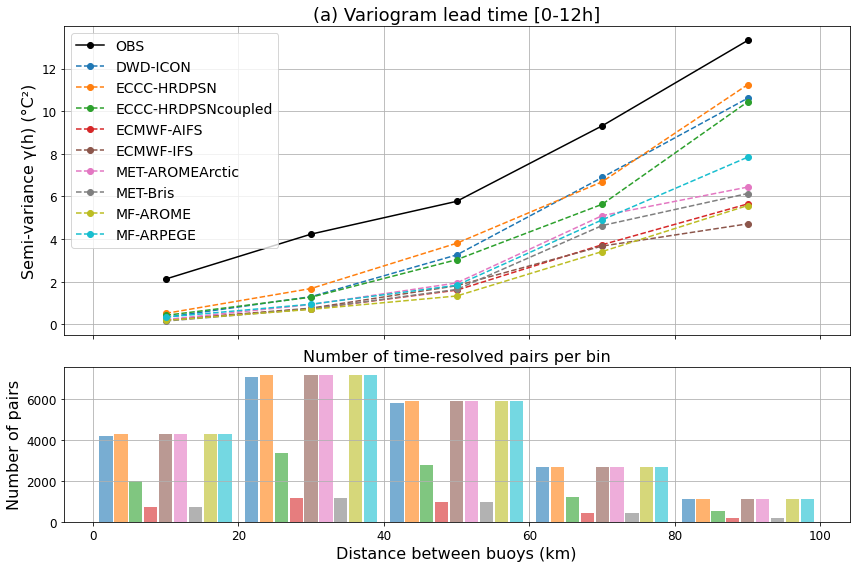

In [77]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, asin

# Haversine distance for arrays
def haversine_array(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Setup
time = ds['time_ds']
n_buoys = ds['temp_1m_calibrated'].shape[0]
models = ds['model'].values
lt_int = 0
bin_width = 20
bins = np.arange(0, 100 + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_bins = len(bin_centers)

# Time filter: 4 April to 30 April 2025
start_date = np.datetime64("2024-04-04")
end_date   = np.datetime64("2024-04-29")
time_mask = (ds['time_ds'] >= start_date) & (ds['time_ds'] <= end_date)
time_indices = np.where(time_mask)[0]

# === OBS variogram ===
all_distances_obs = []
all_semivariances_obs = []

for i, j in itertools.combinations(range(n_buoys), 2):
    temp_i = ds['temp_1m_calibrated'].isel(tr_nr=i, time_ds=time_indices) - 273.15
    temp_j = ds['temp_1m_calibrated'].isel(tr_nr=j, time_ds=time_indices) - 273.15

    flag_i = (ds['temp_flag_1m'].isel(tr_nr=i, time_ds=time_indices) == 1) | \
             (ds['temp_flag_cons'].isel(tr_nr=i, time_ds=time_indices) == 1) | \
             (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=i, time_ds=time_indices) > 300)

    flag_j = (ds['temp_flag_1m'].isel(tr_nr=j, time_ds=time_indices) == 1) | \
             (ds['temp_flag_cons'].isel(tr_nr=j, time_ds=time_indices) == 1) | \
             (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=j, time_ds=time_indices) > 300)

    valid = ~(flag_i | flag_j)

    if valid.sum().item() < 10:
        continue

    ti = temp_i.where(valid).values
    tj = temp_j.where(valid).values
    lati = ds['lat_obs'].isel(tr_nr=i, time_ds=time_indices).where(valid).values
    loni = ds['lon_obs'].isel(tr_nr=i, time_ds=time_indices).where(valid).values
    latj = ds['lat_obs'].isel(tr_nr=j, time_ds=time_indices).where(valid).values
    lonj = ds['lon_obs'].isel(tr_nr=j, time_ds=time_indices).where(valid).values

    temp_diff = ti - tj
    dist = haversine_array(lati, loni, latj, lonj)
    mask = (~np.isnan(temp_diff)) & (~np.isnan(dist)) & (dist <= 100)

    all_distances_obs.extend(dist[mask])
    all_semivariances_obs.extend(0.5 * (temp_diff[mask] ** 2))

all_distances_obs = np.array(all_distances_obs)
all_semivariances_obs = np.array(all_semivariances_obs)
gamma_obs = np.full(n_bins, np.nan)
counts_obs = np.zeros(n_bins, dtype=int)

for k in range(n_bins):
    in_bin = (all_distances_obs >= bins[k]) & (all_distances_obs < bins[k + 1])
    counts_obs[k] = np.sum(in_bin)
    if counts_obs[k] > 0:
        gamma_obs[k] = np.nanmean(all_semivariances_obs[in_bin])

# === Model variograms ===
model_variograms = {}
model_counts = {}

for model_idx, model_name in enumerate(models):
    all_distances_mod = []
    all_semivariances_mod = []

    for i, j in itertools.combinations(range(n_buoys), 2):
        temp_i = ds['T2M'].isel(model=model_idx, lt_int=lt_int, tr_nr=i, time_ds=time_indices) - 273.15
        temp_j = ds['T2M'].isel(model=model_idx, lt_int=lt_int, tr_nr=j, time_ds=time_indices) - 273.15

        flag_i = (ds['temp_flag_1m'].isel(tr_nr=i, time_ds=time_indices) == 1) | \
                 (ds['temp_flag_cons'].isel(tr_nr=i, time_ds=time_indices) == 1) | \
                 (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=i, time_ds=time_indices) > 300)

        flag_j = (ds['temp_flag_1m'].isel(tr_nr=j, time_ds=time_indices) == 1) | \
                 (ds['temp_flag_cons'].isel(tr_nr=j, time_ds=time_indices) == 1) | \
                 (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=j, time_ds=time_indices) > 300)

        valid = ~(flag_i | flag_j)

        if valid.sum().item() < 10:
            continue

        ti = temp_i.where(valid).values
        tj = temp_j.where(valid).values
        lati = ds['lat_obs'].isel(tr_nr=i, time_ds=time_indices).where(valid).values
        loni = ds['lon_obs'].isel(tr_nr=i, time_ds=time_indices).where(valid).values
        latj = ds['lat_obs'].isel(tr_nr=j, time_ds=time_indices).where(valid).values
        lonj = ds['lon_obs'].isel(tr_nr=j, time_ds=time_indices).where(valid).values

        temp_diff = ti - tj
        dist = haversine_array(lati, loni, latj, lonj)
        mask = (~np.isnan(temp_diff)) & (~np.isnan(dist)) & (dist <= 100)

        all_distances_mod.extend(dist[mask])
        all_semivariances_mod.extend(0.5 * (temp_diff[mask] ** 2))

    all_distances_mod = np.array(all_distances_mod)
    all_semivariances_mod = np.array(all_semivariances_mod)

    gamma_model = np.full(n_bins, np.nan)
    count_model = np.zeros(n_bins, dtype=int)

    for k in range(n_bins):
        in_bin = (all_distances_mod >= bins[k]) & (all_distances_mod < bins[k + 1])
        count_model[k] = np.sum(in_bin)
        if count_model[k] > 0:
            gamma_model[k] = np.nanmean(all_semivariances_mod[in_bin])

    model_variograms[str(model_name)] = gamma_model
    model_counts[str(model_name)] = count_model

# === Plotting ===
colors = plt.cm.get_cmap('tab10', len(models))

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top: Variogram
ax1.plot(bin_centers, gamma_obs, marker='o', label='OBS', color='black')

for idx, model_name in enumerate(models):
    ax1.plot(bin_centers, model_variograms[str(model_name)], marker='o', linestyle='--',
             label=str(model_name), color=colors(idx))

ax1.set_ylabel("Semi-variance γ(h) (°C²)", fontsize=16)
ax1.set_title("(a) Variogram lead time [0-12h]", fontsize=18)
ax1.tick_params(labelsize=12)
ax1.grid(True)
ax1.legend(fontsize=14)

# Bottom: Pair counts
bar_width = bin_width / (len(models) + 2)
offsets = np.linspace(-bar_width * len(models) / 2, bar_width * len(models) / 2, len(models))
#ax2.bar(bin_centers, counts_obs, width=bar_width, color='gray', label='OBS')

for idx, model_name in enumerate(models):
    ax2.bar(bin_centers + offsets[idx], model_counts[str(model_name)],
            width=bar_width, label=str(model_name), color=colors(idx), alpha=0.6)

ax2.set_xlabel("Distance between buoys (km)", fontsize=16)
ax2.set_ylabel("Number of pairs", fontsize=16)
ax2.set_title("Number of time-resolved pairs per bin", fontsize=16)
ax2.tick_params(labelsize=12)
ax2.grid(True)
#ax2.legend(fontsize=10)
plt.tight_layout()
plt.savefig("variogram_april2025.png", dpi=300)  # Save the figure
plt.show()
